# Trade-Winds 🌬️
### "The trend is your friend" — the one trading cliché that actually survives the data. But how do you *get paid* for it?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Crisis alpha?: Confirmed](https://img.shields.io/badge/Crisis_alpha%3F-Confirmed-8b949e?style=flat-square)

Almost every clever strategy this desk tests turns out to be a mirage. Here's the exception. Ask each market — stocks, bonds, oil, gold, the euro — one dumb question: *has it been going up or down lately?* Ride the ones going up, short the ones going down, spread your risk evenly across all of them. It's the engine of the entire managed-futures industry, and it has a century of evidence behind it. The twist: on its own it *won't* beat just owning a basket — but it makes money exactly when stocks crash, and **that** turns out to be worth a great deal.

> 📓 **This is the plain-language layer.** The cost & lookback sweeps, the decay, and the crisis-alpha decomposition are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it; the core runs on a **synthetic** trend panel, so the real-futures numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from trade_winds import data, strategy, costs, extension

# Offline synthetic control: regime-switching trend panel (the machinery) + a random-walk null.
# The real 18-futures verdict is in ../docs/results.md.
r, truth = data.synthetic_trends(trend_strength=0.12, seed=31)
r0, _ = data.synthetic_trends(trend_strength=0.0, seed=31)
print(f"synthetic control: {truth.n_markets} markets x {truth.n_days} days, trend_strength {truth.trend_strength} (null=0)")


synthetic control: 18 markets x 5040 days, trend_strength 0.12 (null=0)


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Is trend-following real? | ✅ **Yes.** It pays across every lookback, recovers on our control (Sharpe 2.4 vs the null's 0.2), and has a fat *right* tail (skew +1.50). |
| Does it beat just owning the basket? | 🟡 **No, on its own.** Net Sharpe **0.30** trails the always-long basket (**0.51**) and 60/40 (**0.48**). |
| So why run it? | ⚪ **Crisis alpha.** It makes **+23.6%/yr when stocks crash** (corr **-0.07**); a 30% sleeve lifts a 60/40's Sharpe **0.48→0.56** and halves its drawdown **-34%→-20%**. |

> Desk shorthand: **Signal `REAL` · Tradability `FRAGILE` · Crisis alpha? `CONFIRMED`** — the edge isn't prediction, it's diversification.

## 1 · The claim 📣

Time-series momentum, the steelman the academics actually defend (Moskowitz-Ooi-Pedersen 2012; Hurst-Ooi-Pedersen's *century of evidence* 2017):

1. **Signal** — for each market, the sign of its own trailing 1/3/12-month return. Long if up, short if down.
2. **Equal risk** — divide each position by its own volatility, so a sleepy bond future and a wild gas future take the *same* risk.
3. **Diversify** — hold ~18 markets across four asset classes; the edge is the *portfolio* of thin trend signals, not any one bet.

Crucially this is *time-series* (each market vs its own past), **not** the cross-sectional equity momentum the desk already busted (Studies 24–25) — a different, sturdier animal.

Sharpe 2.44  CAGR 27.3%  skew +0.21


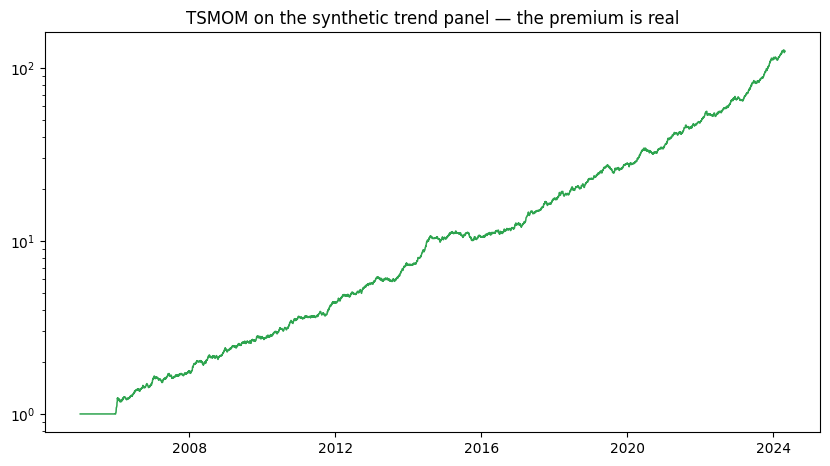

In [2]:
book = strategy.book_returns(r, cost_bps=2.0)
eq = (1+book).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f', lw=1.1)
ax.set_yscale('log'); ax.set_title('TSMOM on the synthetic trend panel — the premium is real')
s = strategy.summary(book); print(f"Sharpe {s['sharpe']:.2f}  CAGR {s['cagr']*100:.1f}%  skew {s['skew']:+.2f}")

## 2 · So what? 💰

A real, decorrelated return stream is the holy grail of portfolio construction — far more useful than yet another thing correlated to stocks. Trend-following is the biggest, oldest example a retail trader can actually access (via futures or managed-futures ETFs). The desk's question isn't *'is it real'* (it is) — it's the subtler one: does the *timing* earn its keep, or is owning a diversified basket already most of the prize?

## 3 · How we'd know 🔬

1. **Real?** Does the book pay on the control and across lookbacks, and stay flat on a random-walk null?
2. **Standalone edge?** Net Sharpe vs the *always-long* basket of the same markets, and vs 60/40.
3. **Crisis alpha?** Its return in the worst equity months, and its correlation to stocks.
4. **The payoff:** does blending a sleeve into a normal portfolio raise Sharpe / cut drawdown?

**Fragile line:** standalone net Sharpe below the long-only basket — the timing adds nothing alone.

## 4 · The teardown 🔧

### 4a · Real on the control, nothing on the null

In [3]:
for label, rr in [('trend panel', r), ('null (random walk)', r0)]:
    s = strategy.summary(strategy.book_returns(rr, cost_bps=2.0))
    print(f"{label:20} Sharpe {s['sharpe']:+.2f}  skew {s['skew']:+.2f}")

trend panel          Sharpe +2.44  skew +0.21
null (random walk)   Sharpe +0.22  skew +0.09


### 4b · On the real tape — fragile alone, but real crisis alpha
On 18 real futures, 2000–2026 ([`../docs/results.md`](../docs/results.md)):

- Standalone net Sharpe **0.30** — *below* the always-long basket (**0.51**) and 60/40 (**0.48**). The timing alone doesn't clear the bar.
- But it earns **+23.6%/yr in the worst 31 equity months** vs +1.1% the rest of the time, at **-0.07** correlation to stocks — textbook crisis alpha.
- Sub-period Sharpe **+0.83 / -0.28 / +0.29** — it worked, endured the 2010s drought, then revived. A real premium with real lean years.

### 4c · The payoff — trend as a portfolio diversifier

In [4]:
eqr = r['MKT00'].reindex(book.index)   # a stand-in 'equities' sleeve on the synthetic
def st(x):
    s = strategy.summary(x); return f"Sharpe {s['sharpe']:.2f}  maxDD {s['max_drawdown']*100:.0f}%"
print('one market alone       ', st(eqr))
print('70% market / 30% trend ', st(0.7*eqr + 0.3*book))
print('\nReal portfolios (../docs/results.md):')
print('  equities only            Sharpe 0.43  maxDD -57%')
print('  60% equities / 40% trend Sharpe 0.52  maxDD -33%')
print('  60/40 only               Sharpe 0.48  maxDD -34%')
print('  70% 60/40 / 30% trend    Sharpe 0.56  maxDD -20%')

one market alone        Sharpe -0.18  maxDD -71%
70% market / 30% trend  Sharpe 0.46  maxDD -41%

Real portfolios (../docs/results.md):
  equities only            Sharpe 0.43  maxDD -57%
  60% equities / 40% trend Sharpe 0.52  maxDD -33%
  60/40 only               Sharpe 0.48  maxDD -34%
  70% 60/40 / 30% trend    Sharpe 0.56  maxDD -20%


> 🔬 **For the quants.** Because the book is ~−0.07 correlated to equities with positive skew, adding it *raises* a portfolio's Sharpe **and** cuts its drawdown at the same time — the genuine free-ish lunch of diversification, not a timing miracle.

## 5 · The verdict 🧾

- **Real premium** — control Sharpe 2.4 vs null 0.2; positive across lookbacks; +skew.
- **Fragile standalone** — net Sharpe 0.30 < long-only basket 0.51; a decade-long drought.
- **Crisis alpha confirmed** — +23.6%/yr in equity crises, corr -0.07; a 30% sleeve lifts 60/40 Sharpe 0.48→0.56, drawdown -34%→-20%.

> **Signal `REAL` · Tradability `FRAGILE` · Crisis alpha? `CONFIRMED`.** Not a standalone money machine — decorrelated insurance that pays you to hold it.

## 6 · Could you trade it? 💸

- **Yes — but as a *sleeve*, not the whole book.** Run 20–40% trend alongside your stocks/bonds; the −0.07 correlation does the work. As 100% of your money it under-earns the basket.
- **Costs are friendly.** Futures embed carry in the price (no CFD-style full-notional financing — see Study 30), and the basket is the most liquid stuff alive; the book breaks even around 5 bp and trades slowly.
- **The price of admission is patience.** You must sit through droughts like 2011–2019 to collect the crisis payoff in 2008, 2020, 2022. Most people can't, which is partly why it persists.

## 7 · Going further 🚪

### Worked complement — breadth is the lever ([`../docs/extension.md`](../docs/extension.md))
We widened from the 18 futures to a **27-market** liquid-ETF universe and swept the Sharpe against the number of markets:

- One market trends at Sharpe ~**0.20**; spreading the same signal over more markets lifts it monotonically — **0.46** at 8, **0.51** at 16, **0.55** at all 27.
- The full wider book's standalone Sharpe is **0.55** — *above* the basket (0.51) and 60/40 (0.48) that the narrow 18-market book trailed. **The `FRAGILE` standalone verdict was largely a breadth limitation** — and the curve is still rising at 27, which is why real managed futures runs 50–100+ markets.

### Other forks
- **More breadth still** — single-stock futures, more rates/FX; the sweep says Sharpe keeps climbing.
- **Combine with carry** — trend + carry is the classic two-premium managed-futures core.
- **Right-size the sleeve for *your* portfolio** — fork the blend cell and solve the weight.

PRs welcome — widen the universe further, add a carry sleeve, or optimise the portfolio weight.